A Monte Carlo simulation for stock prices uses Geometric Brownian Motion (GBM) to project future prices by modeling random, daily price movements based on historical volatility and drift. 

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import yfinance as yf

Simulation Process:
- Input parameters; obtain current stock price, drift(mu) and volatility (sigma).
- Generate Randomness: Generate random normal variables (E) for every day and trial.
- Calculate Path: Iterate the formula to calculate future prices, typically running thousands of trials to create a range of possible outcomes.

In [ ]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

prices = yf.Ticker('AAPL').history(period='1y')['Close']

# Calculate returns using logs, this makes the returns additive.
log_returns = np.log(prices / prices.shift(1)).dropna()

mu = log_returns.mean() * 252 # expected mean return over a trading year
sigma = log_returns.std()  * np.sqrt(252) # standard deviation of returns
S0 = prices.iloc[-1] # starting stock price

N_SIMS, T_DAYS, dt = 1000, 252, 1/252
np.random.seed(42)

# A grid of 500 × 252 random numbers drawn from a normal distribution (mean 0, std 1). Each number is one day's random shock for one simulation. This is what makes every path different.
Z = np.random.standard_normal((N_SIMS, T_DAYS))

# Using the Geometric Brownian Motion formula to project future prices
daily_log_ret = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
paths = S0 * np.exp(np.hstack([np.zeros((N_SIMS, 1)), np.cumsum(daily_log_ret, axis=1)]))

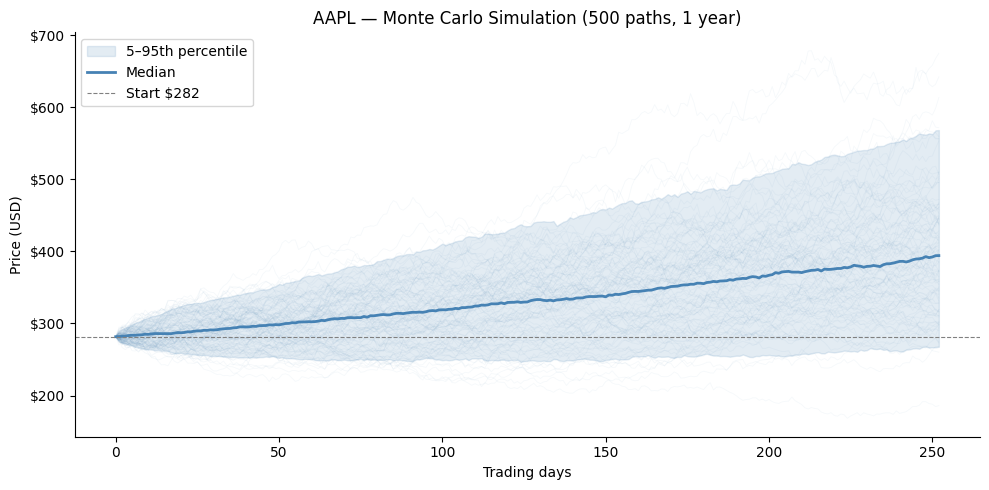

In [26]:
days = np.arange(T_DAYS + 1)
p5   = np.percentile(paths,  5, axis=0)
p50  = np.percentile(paths, 50, axis=0)
p95  = np.percentile(paths, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 5))

# A sample of individual paths (faint)
for i in range(100):
    ax.plot(days, paths[i], color='steelblue', alpha=0.05, linewidth=0.6)

# Percentile band and median
ax.fill_between(days, p5, p95, color='steelblue', alpha=0.15, label='5–95th percentile')
ax.plot(days, p50, color='steelblue', linewidth=2, label='Median')
ax.axhline(S0, color='grey', linewidth=0.8, linestyle='--', label=f'Start ${S0:.0f}')

ax.set_title('AAPL — Monte Carlo Simulation (500 paths, 1 year)')
ax.set_xlabel('Trading days')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()